
We will demonstrate our work in Caltech Ducted fan in hover mode described by:
\begin{align*}
    \begin{bmatrix}
        \dot{x}\\
        \dot{y}\\
        \dot{\theta}\\
        \ddot{x}\\
        \ddot{y}\\
        \ddot{\theta}
    \end{bmatrix}&= 
    \begin{bmatrix}
        u \\
        v \\
        w \\
        \frac{-d u + u_1 \cos( \theta) - u_2 \sin(\theta)}{m}\\
        \frac{d v + u_1 \sin(\theta) - u_2 \cos(\theta) - mg}{m}\\
        \frac{r u_1}{I}
    \end{bmatrix}\\
            &= \begin{bmatrix}
                u \\
                v \\
                w \\
                \frac{-d u}{m} \\
                \frac{-d v-mg}{m} \\
                0
            \end{bmatrix} + 
            u_1\begin{bmatrix}
                0\\
                0\\
                0\\ 
                \frac{\cos (\theta)}{m} \\
                \frac{\sin (\theta)}{m} \\
                \frac{r}{I}
            \end{bmatrix} + 
            u_2 \begin{bmatrix}
                0\\
                0\\
                0\\
                - \frac{\sin (\theta)}{m}\\
                -\frac{\cos (\theta)}{m}\\
                0
            \end{bmatrix}\\
            &=\begin{bmatrix}
                u \\
                v \\
                w \\
                \frac{-d u}{m} \\
                \frac{-d v-mg}{m} \\
                0
            \end{bmatrix} + \begin{bmatrix}
            0 & 0 \\
            0 & 0 \\
            0 & 0 \\
            \frac{\cos (\theta)}{m} & - \frac{\sin (\theta)}{m} \\
            \frac{\sin (\theta)}{m} & -\frac{\cos (\theta)}{m}\\
            \frac{r}{I} & 0
            \end{bmatrix} \begin{bmatrix}
            u_1 \\
            u_2
            \end{bmatrix}\\
            \text{i.e.}\\
            f(x,u)&= f(x)+g(x)u(x)
\end{align*}
where,
\begin{align*}
    x &= \begin{bmatrix}
        x & y & \theta & u & v & w
    \end{bmatrix}^T\\
    f(x,u) &= \begin{bmatrix}
        \dot{x}\\
        \dot{y}\\
        \dot{\theta}\\
        \ddot{x}\\
        \ddot{y}\\
        \ddot{\theta}
    \end{bmatrix}\\
    f(x) &= \begin{bmatrix}
                u \\
                v \\
                w \\
                \frac{-d u}{m} \\
                \frac{-d v-mg}{m} \\
                0
            \end{bmatrix}, \quad g(x) =\begin{bmatrix}
            0 & 0 \\
            0 & 0 \\
            0 & 0 \\
            \frac{\cos (\theta)}{m} & - \frac{\sin (\theta)}{m} \\
            \frac{\sin (\theta)}{m} & -\frac{\cos (\theta)}{m}\\
            \frac{r}{I} & 0
            \end{bmatrix} \quad u(x) = \begin{bmatrix}
            u_1 \\
            u_2
            \end{bmatrix}
\end{align*}

so, the divergence condition for the same becomes:
\begin{align*}
    \nabla . ( \rho(f + gu)) &> 0\\
    \nabla . (\rho f + g \rho u) & > 0\\
    \nabla. (\rho f + g \Psi) & > 0
\end{align*}
where $f \in R^6, g \in R^{6 \times 2}, \rho \in R^1$ and $\Psi \in R^2$


# Breaking down divergence into simpler terms:
If g were to be represented by the $g_1$ and $g_2$, i.e. $g =[ g_1, g_2]$ where $g_1,g_2 \in R^6$.
Let $ [ \Psi_1, \Psi_2]$ represent $\Psi$ and $\Psi_1,\Psi_2 \in R$ 
Recall:
\begin{align*}
    \nabla . ( \rho f + g \Psi) &> 0\\
    \nabla . (\rho f) + \nabla . (g \Psi) & > 0\\
    \nabla . (\rho f) + \nabla . (\Psi_1. g_1 + \Psi_2. g_2) & > 0\\
    \nabla . (\rho f) + \nabla . (\Psi_1. g_1) + \nabla . (\Psi_2. g_2) & > 0\\
    \rho \nabla . f + f \nabla \rho + \Psi_1 \nabla . g_1 + g_1\nabla \Psi_1  +  \Psi_2 \nabla . g_2 +  g_2 \nabla \Psi_2  & > 0\\
\end{align*}

# Final Loss function:
So, the constraints are reduced as:
1. $\rho(x) > 0$
2. $\rho \nabla . f + f \nabla \rho + \Psi_1 \nabla . g_1 + g_1\nabla \Psi_1  +  \Psi_2 \nabla . g_2 +  g_2 \nabla \Psi_2  > 0$

Now, this problem can be thought of training three neural networks since evaluating loss would be easier this way. and let us just write $f(x,u)$ as well in terms of $g_1$ and $g_2$. 
\begin{align*}
    f(x,u)&=f(x)+g(x)u(x)\\
    &=f(x)+u_1(x)g_1(x)+u_2(x)g_2(x)\\
    \text{where}\\
    g_1&= \begin{bmatrix}
                0\\
                0\\
                0\\ 
                \frac{\cos (\theta)}{m} \\
                \frac{\sin (\theta)}{m} \\
                \frac{r}{I}
            \end{bmatrix}, \quad
    g_2= \begin{bmatrix}
                0\\
                0\\
                0\\
                - \frac{\sin (\theta)}{m}\\
                -\frac{\cos (\theta)}{m}\\
                0
            \end{bmatrix}
\end{align*}

Please note that, you can still choose to train only two neural networks but your $\Psi$'s output must be $R^2$ and have to change the functions accordingly.

# Pre-Computed Divergence:
Instead of falling for the trap of numerical instability, we will precompute the divergence as:
\begin{align*}
    \nabla . f &= \frac{\partial u}{\partial x} +\frac{\partial v}{\partial y} + \frac{\partial w}{\partial \theta} + \frac{\partial -du/m}{\partial u} + \frac{\partial (-dv-mg)/m}{\partial v} + \frac{\partial 0}{\partial w}\\
    &= -\frac{d}{m}-\frac{d}{m}\\
    &= -\frac{2d}{m}
\end{align*}
and,
\begin{align*}
    \nabla. g_1 &= 0 \\
    \nabla. g_2 &= 0
\end{align*}

# fix the constants:

1. g = 0.28
2. m = 11.2
3. I = 0.0462
4. r = 0.156
5. d = 0.1


In [1]:
import torch

torch.cuda.empty_cache()  # Clear the GPU memory cache


In [2]:
# -*- coding: utf-8 -*-
from dreal import *
# from Functions import *
import torch 
import torch.nn.functional as F
import numpy as np
import timeit 
import matplotlib.pyplot as plt

import random

In [3]:
torch.manual_seed(42)

random.seed()



In [4]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:1


# Define your variables or states:
your x should be:
\begin{align*}
    x &= \begin{bmatrix}
        x & y & \theta & \dot{x} & \dot{y} & \dot{\theta}
    \end{bmatrix}^T
\end{align*}

In [5]:
numerical_x = torch.Tensor(100, 6).uniform_(-1, 1).float()
numerical_x = numerical_x.to(device)  

# SMT Solvers


In [6]:


def Checkdivergence(vars,rho_learnt, divergence,  ball_lb, ball_ub, config, epsilon=0):
    """ Checkdivergence takes two necessary arguments which are
     vars and rho_learnt. rho_learnt is basically f \rho - g u \rho.
      we must check if divergence of ( f \rho - g u \rho) > epsilon """
    ball = Expression(0)


    # Construct ball constraint
    ball = vars[0]**2 + vars[1]**2 + vars[2]**2 +vars[3]**2 + vars[4]**2 + vars[5]**2
    ball_in_bound = logical_and(ball_lb <= ball, ball <= ball_ub)

    # Convert rho_learnt to a Formula
    rho_term = rho_learnt > 0

    # Stability conditions: divergence > epsilon and rho > 0
    divergence_condition = divergence > epsilon
    stability_condition = logical_and(
        logical_imply(ball_in_bound, divergence_condition),
        logical_imply(ball_in_bound, rho_term)
    )

    # Check satisfiability of the negation of the condition
    return CheckSatisfiability(logical_not(stability_condition), config)



def AddCounterexamples(x, CE, N, device):
    """
    Adds counterexamples to the sample set `x`.
    
    Args:
        x: Existing tensor of samples.
        CE: Counterexample intervals from `Checkdivergence`.
        N: Number of nearby points to add for each counterexample.
        device: Device where tensors are stored (e.g., `cuda:1`).

    Returns:
        Updated tensor with counterexamples added.
    """
    nearby = []
    for i in range(CE.size()):
        lb = CE[i].lb()
        ub = CE[i].ub()
        nearby_ = np.random.uniform(lb, ub, N)  # Generate nearby points
        nearby.append(nearby_)
    
    for i in range(N):
        n_pt = []
        for j in range(x.shape[1]):
            n_pt.append(nearby[j][i])  # Collect one point from each dimension
        # Add the point to `x` on the correct device
        n_pt_tensor = torch.tensor([n_pt], dtype=torch.float32, device=device)
        x = torch.cat((x, n_pt_tensor), dim=0)
        x= torch.unique(x, dim=0)

    return x, n_pt_tensor


In [7]:
import math

def f_value(f_val, g_val_1,g_val_2, u_1,u_2):
    """
    The dynamical system is defined as f(x)+g(x)u
    where f(x) and g(x) are functions of x and u is the control
    input. This function returns the value of the dynamical system
    at x with control input u.
    """
    return f_val + g_val_1 * u_1 + g_val_2 * u_2

def f(x): 
    g = 0.28
    m = 11.2
    I = 0.0462
    r = 0.156
    d = 0.1
    # Use torch.sin instead of math.sin
    val = torch.tensor([x[3],x[4],x[5], -d *x[0]/m , (-d * x[1]- m *g) /m,0], device=device)
    return val


def g_1(x):
    g = 0.28
    m = 11.2
    I = 0.0462
    r = 0.156
    d = 0.1

    return torch.tensor([0,0,0,torch.cos(x[2])/m,torch.sin(x[2])/m, r/I], device=device)

def g_2(x):
    g = 0.28
    m = 11.2
    I = 0.0462
    r = 0.156
    d = 0.1

    return torch.tensor([0,0,0,-torch.sin(x[2])/m,-torch.cos(x[2])/m,0], device=device)



In [8]:
import torch.nn as nn

class DensityFunctionNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DensityFunctionNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)


class GammaFunctionNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GammaFunctionNet, self).__init__()
        self.linear_layer = nn.Linear(input_dim, output_dim)
        
        # Initialize weights to zero and bias to zero (or any desired value)
        nn.init.constant_(self.linear_layer.weight, 0)
        nn.init.constant_(self.linear_layer.bias, 0)

        # Freeze weights to ensure they cannot be updated
        self.linear_layer.weight.requires_grad = False

    def forward(self, x):
        # Directly return the bias as output
        return self.linear_layer.bias




In [9]:
def gradient_at_given_function(func,x):
    """ The function returns the gradient of given function at x"""
    # Ensure x requires gradients
    x = x.clone().detach().requires_grad_(True)
    
   # Compute the output of the function
    output = func(x.unsqueeze(0))  # Add batch dimension (shape: [1, input_dim])
    
    # Extract scalar from output tensor
    output = output.squeeze()  # Remove batch and channel dimensions (shape: ())
    
    # Ensure the function returns a scalar
    if output.dim() != 0:
        raise ValueError(f"The function must return a scalar value, but got shape {output.shape}.")
    
    # Compute the gradient
    grad = torch.autograd.grad(outputs=output, inputs=x, create_graph=True)[0]
    
    return grad

def div_f(x):
    d = 0.1
    m = 11.2
    term = - 2 * d / m
    return torch.tensor(term, device=device)

def div_g(x):
    term = 0 
    return torch.tensor(term, device=device)

def control_density_risk2(x, rho_in, u_rho_in_1, u_rho_in_2, fu, gu_1, gu_2):
    ret_Val = []
    for i in range(x.shape[0]):
        divergence_at_f = div_f(x[i])
        grad_at_rho = gradient_at_given_function(rho_in, x[i])
        grad_at_u_rho_1 = gradient_at_given_function(u_rho_in_1, x[i])
        
        grad_at_u_rho_2 = gradient_at_given_function(u_rho_in_2, x[i])
    
        val = rho_in(x[i]) * divergence_at_f + grad_at_rho @ fu(x[i]) + grad_at_u_rho_1 @ gu_1(x[i]) + grad_at_u_rho_2 @ gu_2(x[i])
        ret_Val.append(val)
    ret_Val = torch.stack(ret_Val)
    return ret_Val


In [10]:


def control_density_loss(x, rho_in, u_rho_in_1, u_rho_in_2, fu, gu_1, gu_2, gamma):
    divergence2 = control_density_risk2(x, rho_in, u_rho_in_1, u_rho_in_2, fu, gu_1, gu_2)
    loss2 = F.relu(gamma(x)-divergence2).mean()
    rho = rho_in(x)
    rho_loss = F.relu(-rho).mean()
    gamma_loss = F.relu(-gamma(x)).mean()
    return loss2 + rho_loss + gamma_loss




In [11]:
class SymbolicNN:
    """
    A helper class to convert neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights) - 1):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # Apply tanh activation
            z = [tanh(zi) for zi in z]
        
        # Final linear layer without activation
        z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out

def candidate_constraint_learnt(vars, rho_in, u_rho_in_1, u_rho_in_2):
    """Compute the candidate constraint"""
    rho = SymbolicNN(rho_in)
    u_rho_1 = SymbolicNN(u_rho_in_1)
    u_rho_2 = SymbolicNN(u_rho_in_2)
    
    # Get Symbolic Forward Pass
    rho_out = rho.forward_symbolic(vars)
    u_rho_out_1 = u_rho_1.forward_symbolic(vars)
    u_rho_out_2 = u_rho_2.forward_symbolic(vars)
    
    g = 0.28
    m = 11.2
    I = 0.0462
    r = 0.156
    d = 0.1

    # Compute vector field as symbolic expressions
    f_val = [
        vars[3],vars[4],vars[5], -d *vars[0]/m , (-d * vars[1]- m *g) /m,0
    ]  # f(x)
    g_val_1 = [0,0,0,cos(vars[2])/m,sin(vars[2])/m, r/I]  # g(x)
    g_val_2 = [0,0,0,-sin(vars[2])/m,-cos(vars[2])/m,0]  # g(x)

    # Compute f*rho + g*u_rho (element-wise multiplication)
    vector_field = [
        f_val[i] * rho_out[0] + g_val_1[i] * u_rho_out_1[0] + g_val_2[i] * u_rho_out_2[0]
        for i in range(len(vars)) 
    ]

    # Compute divergence as the sum of partial derivatives
    divergence = sum(
        vector_field[i].Differentiate(vars[i])
        for i in range(len(vars))
    )

    return divergence, rho_out[0]



In [12]:
config = Config()
config.use_polytope_in_forall = True
config.use_local_optimization = True
config.precision = 1e-5
epsilon = 0

ball_lb = 0.5
ball_ub = 6
# x1 = Variable("x1")
# x2 = Variable("x2")
# x3 = Variable("x3")
# x4 = Variable("x4")
# x5 = Variable("x5")
# x6 = Variable("x6")


In [13]:

def train_density(x,epochs=2000, learning_rate=1e-1):
    loss_total_density = []
    valid = False

    rho_nn = DensityFunctionNet(input_dim=6, hidden_dim=6, output_dim=1).to(device)
    u_rho_nn_1 = DensityFunctionNet(input_dim=6, hidden_dim=6, output_dim=1).to(device)
    u_rho_nn_2 = DensityFunctionNet(input_dim=6, hidden_dim=6, output_dim=1).to(device)
    gamma_nn = GammaFunctionNet(input_dim=6, output_dim=1).to(device)

    optimizer = torch.optim.SGD(
        list(rho_nn.parameters()) + list(u_rho_nn_1.parameters()) + list(u_rho_nn_2.parameters()) + list(gamma_nn.parameters()),
        lr=learning_rate
    )

    # optimizer = torch.optim.Adam(
    #     list(rho_nn.parameters()) + list(u_rho_nn_1.parameters()) + list(u_rho_nn_2.parameters()) + list(gamma_nn.parameters()),
    #     lr=learning_rate
    # )

    print("Start the training")
    while not valid:
        for epoch in range(epochs):
            optimizer.zero_grad()

            # compute losses
            loss = control_density_loss(x, rho_nn, u_rho_nn_1, u_rho_nn_2, f,g_1,g_2, gamma_nn)

            # BackPropagation
            loss.backward()
            optimizer.step()
            
            print(f"Epoch : {epoch}, current loss: {loss.item()}")
            loss_total_density.append(loss.item())

            if loss.item() == 0:
                valid = True
                break

            # check counter examples 
            if epoch % 10 == 0 :
                vars = [Variable("x1"), Variable("x2"),Variable("x3"), Variable("x4"),Variable("x5"), Variable("x6")]
                divergence_learnt, rho_learnt = candidate_constraint_learnt(vars, rho_nn, u_rho_nn_1, u_rho_nn_2)
                result = Checkdivergence(vars, rho_learnt, divergence_learnt,  ball_lb, ball_ub, config,0)

                if (result):
                    print("_______________________________________________________")
                    print("Not a Density function")
                    print(result)
                    x , counter_example = AddCounterexamples(x,result,N=10,device=device)
                    risk_examine = control_density_risk2(counter_example, rho_nn, u_rho_nn_1, u_rho_nn_2, f,g_1,g_2)
                    rho_examine = rho_nn(counter_example)
                    print(f"observe condition 01, {risk_examine}")
                    print(f"observe condition 02, {rho_examine}")
                    print("_______________________________________________________")
                else:
                    valid = True
                    print("Conditions are satisfied!")
                    
    print(f"The learned margin is {gamma_nn(x)}")
    return loss_total_density, rho_nn, u_rho_nn_1, u_rho_nn_2, gamma_nn
        


In [14]:
def plot_results(risks, labels):
    plt.figure(figsize=(10, 6))
    for risk, label in zip(risks, labels):
        plt.plot(risk, label=label)
    plt.xlabel("Iteration")
    plt.ylabel("Risk")
    plt.title("Risk Over Iterations")
    plt.legend()
    plt.grid()
    plt.show()


In [15]:

loss_density, rho_nn, u_rho_nn_1,  u_rho_nn_2, gamma_nn = train_density(numerical_x,epochs=2000, learning_rate=1e-1)


Start the training
Epoch : 0, current loss: 0.373123437166214
_______________________________________________________
Not a Density function
x1 : [-1.1680077279964344e-06, 0]
x2 : [0, 1.1680077279964344e-06]
x3 : [-1.1099227036831716, -1.1099203676677156]
x4 : [1.4016092735957212e-05, 1.5184100463953646e-05]
x5 : [-1.1680077279964344e-06, 0]
x6 : [0.0035834477094930607, 0.0035857837249490534]
observe condition 01, tensor([[1.4508]], device='cuda:1', grad_fn=<StackBackward0>)
observe condition 02, tensor([[3.7849e-06]], device='cuda:1', grad_fn=<AddmmBackward0>)
_______________________________________________________
Epoch : 1, current loss: 0.22288475930690765
Epoch : 2, current loss: 0.15669205784797668
Epoch : 3, current loss: 0.10797341912984848
Epoch : 4, current loss: 0.0733267068862915
Epoch : 5, current loss: 0.05007036030292511
Epoch : 6, current loss: 0.0339999683201313
Epoch : 7, current loss: 0.025235138833522797
Epoch : 8, current loss: 0.020339669659733772
Epoch : 9, curre

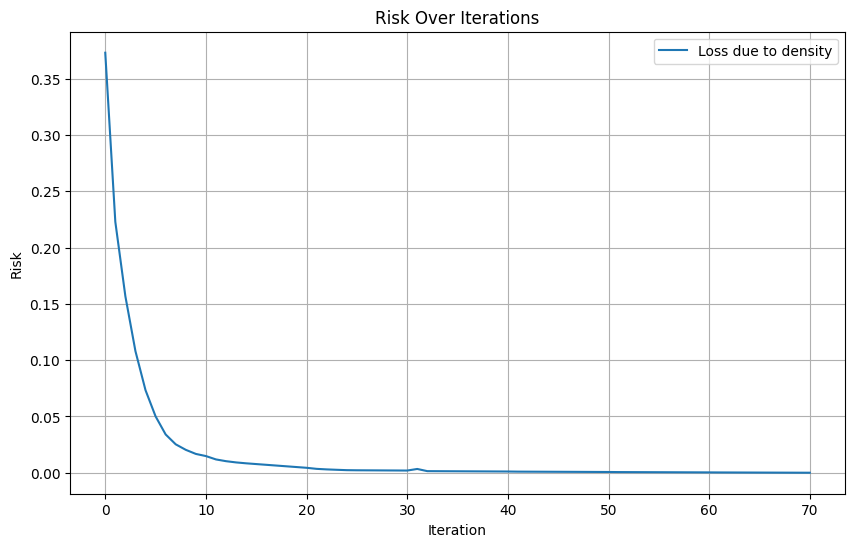

In [20]:

risks = []
risks.append(loss_density)

plot_results(risks, labels=[f"Loss due to {d}" for d in ['density']])


In [21]:
# Parameters
grid_size = 10  # Grid resolution

# Define grid for x1 and x2
x1 = torch.linspace(-1, 1, grid_size)
x2 = torch.linspace(-1, 1, grid_size)
x1_grid, x2_grid = torch.meshgrid(x1, x2)

# Generate random values for x3, x4, x5, and x6 in [-1, 1]
x3 = torch.rand(1) * 2 - 1  # Single random value in [-1, 1]
x4 = torch.rand(1) * 2 - 1
x5 = torch.rand(1) * 2 - 1
x6 = torch.rand(1) * 2 - 1

# Repeat x3, x4, x5, x6 to match the size of x1_grid and x2_grid
x3_grid = x3.expand_as(x1_grid)
x4_grid = x4.expand_as(x1_grid)
x5_grid = x5.expand_as(x1_grid)
x6_grid = x6.expand_as(x1_grid)

# Stack grid points into shape [num_points, 6]
grid_points = torch.stack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel(), x4_grid.ravel(), x5_grid.ravel(), x6_grid.ravel()], dim=1).to(device)

# Compute divergence set for the grid points
divergence_set = control_density_risk2(grid_points, rho_nn, u_rho_nn_1, u_rho_nn_2, f, g_1, g_2)

# Rescale the values to 1 and -1 for x >= 0 and x < 0 respectively
divergence_set = torch.where(divergence_set >= 0, 1, -1)

# Reshape divergence values to match the x1-x2 grid dimensions
divergence_values_reshaped = divergence_set.detach().cpu().numpy().reshape(grid_size, grid_size)


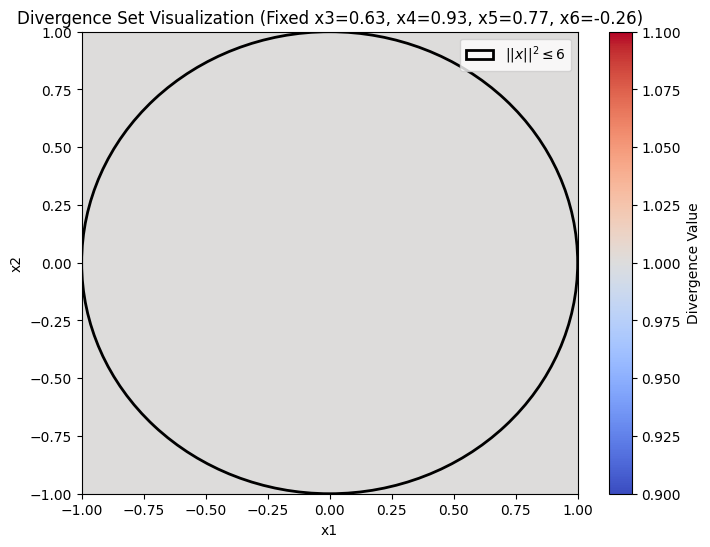

In [22]:
import matplotlib.patches as patches

# Visualization
plt.figure(figsize=(8, 6))
plt.imshow(
    divergence_values_reshaped,
    extent=[-1, 1, -1, 1],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="Divergence Value")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f"Divergence Set Visualization (Fixed x3={x3.item():.2f}, x4={x4.item():.2f}, x5={x5.item():.2f}, x6={x6.item():.2f})")

# Add a circle to the plot
circle = patches.Circle((0, 0), 1, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 6$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()


In [23]:
# Count the total number of values in the divergence set
total_values = divergence_values_reshaped.size

# Count the number of negative values
negative_values_count = (divergence_values_reshaped < 0).sum()

# Calculate the percentage of negative values
percentage_negative = negative_values_count 

print(f"The percentage of negative values in divergence_values_reshaped is {percentage_negative:.2f}")

# # PRINT the negative values taken by the divergence
# negative_values = divergence_values_reshaped[divergence_values_reshaped < 0]
# print(f"The negative values in divergence_values_reshaped are {negative_values}")

The percentage of negative values in divergence_values_reshaped is 0.00
